# 29회 실기

## 1-1

계약자고유번호를 기준으로 거주연도 별 여러개의 데이터가 쌓여 있다. 각 계약자고유번호에 대해 가장 최신의 거주연도 행만 남겨라.  
- 데이터 출처 : https://www.data.go.kr/data/15094266/fileData.do 후처리
- 데이터 링크 : https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/29/p1.csv

- 데이터 설명 : 대구도시공사 빅데이터 영구임대아파트 입주자 퇴거여부 데이터, 고유번호를 가진 계약자와 특정 아파트에 대해 매년 퇴거여부를 기록한 데이터

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import warnings

warnings.filterwarnings('ignore')

d1=pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/29/p1.csv',encoding= 'cp949')

In [63]:
d1 = d1.sort_values(by=['순번', '거주연도'], ascending=True).groupby('순번').tail(1)

d1.head()

,순번,계약구분,재계약횟수,거주개월,아파트 이름,아파트 ID,아파트 평점,호실고유번호,층,평형대,...,퇴거연도,거주연도,월세(원),보증금(원),대표나이,나이,성별,결혼여부,거주자 수,퇴거여부
12,1,유효,10,222,강남아파트,5,7.0,14520,1,12,...,NaN,2020,152040,11774400,46,45,남,미혼,3,미퇴거
17,2,해지,5,108,강남아파트,5,7.0,14546,1,12,...,2012.0,2012,69900,5408000,68,59,여,미혼,1,퇴거
24,3,해지,4,81,강남아파트,5,7.0,14546,1,12,...,2019.0,2019,45700,3197000,51,49,여,미혼,3,퇴거
25,4,유효,1,8,강남아파트,5,7.0,14546,1,12,...,NaN,2020,38000,2078000,66,65,남,미혼,1,미퇴거
38,5,유효,10,222,강남아파트,5,7.0,14572,1,15,...,NaN,2020,126300,9780000,77,76,여,미혼,2,미퇴거


이렇게 하면 각 순번별로 거주연도 기준 최신 데이터만 남길 수 있다. 

## 1-2 EDA 및 결측치 처리 (시각화 포함)

In [64]:
print(d1.info())

d1.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10472 entries, 12 to 86903
Data columns (total 23 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   순번       10472 non-null  int64  
 1   계약구분     10410 non-null  object 
 2   재계약횟수    10472 non-null  int64  
 3   거주개월     10472 non-null  int64  
 4   아파트 이름   10472 non-null  object 
 5   아파트 ID   10472 non-null  int64  
 6   아파트 평점   10330 non-null  float64
 7   호실고유번호   10472 non-null  int64  
 8   층        10472 non-null  int64  
 9   평형대      10472 non-null  int64  
 10  계약자고유번호  10472 non-null  int64  
 11  계약서고유번호  10472 non-null  int64  
 12  입주연도     10472 non-null  int64  
 13  퇴거연도     4214 non-null   float64
 14  거주연도     10472 non-null  int64  
 15  월세(원)    10472 non-null  int64  
 16  보증금(원)   10472 non-null  int64  
 17  대표나이     10472 non-null  int64  
 18  나이       10472 non-null  int64  
 19  성별       10472 non-null  object 
 20  결혼여부     10472 non-null  object 
 21  거주자 수    10

순번            0
계약구분         62
재계약횟수         0
거주개월          0
아파트 이름        0
아파트 ID        0
아파트 평점      142
호실고유번호        0
층             0
평형대           0
계약자고유번호       0
계약서고유번호       0
입주연도          0
퇴거연도       6258
거주연도          0
월세(원)         0
보증금(원)        0
대표나이          0
나이            0
성별            0
결혼여부          0
거주자 수         0
퇴거여부          0
dtype: int64

순번, 계약자 고유번호, 계약서 고유번호, 호실 고유번호는 식별자 역할만 하며 데이터로서 의미가 없으므로 추후 삭제한다.  
입주, 거주, 퇴거연도는 연속형 변수가 아니므로 object 형으로 변환해준다.

결측치가 있는 컬럼이 3개 존재한다.  
- 계약구분, 아파트 평점 결측치는 데이터를 더 살펴본 후 적절한 대푯값으로 치환 또는 삭제하고,  
- 퇴계연도는 미퇴거의 경우 빈 값이 있을 수 있으며, 거주연도/거주개월/퇴거여부 변수가 유사한 정보를 가지고 있으므로  
  모든 결측치가 미퇴거인 경우 해당컬럼을 사용하지 않는다.

In [65]:
d1[d1['퇴거연도'].isna()]['퇴거여부'].value_counts()

미퇴거    6258
Name: 퇴거여부, dtype: int64

In [66]:
d1.drop(columns='퇴거연도', inplace=True)

퇴거연도의 결측치의 경우 모두 미퇴거인 경우이다. 따라서 해당 컬럼은 사용하지 않는다. 

계약구분은 "유효" 와 "해지" 두 가지 종류가 있다. 퇴거여부를 확인해서 "퇴거"이면 해지, "미퇴거"이면 유효로 결측치를 채워준다. 

In [67]:
d1['계약구분'] = np.where(d1['퇴거여부'] == '퇴거', "해지", "유효")

아파트 평점은 아파트 이름별로 동일하므로 해당 아파트에 맞는 평점을 채워준다. 

In [68]:
d1.groupby('아파트 이름')['아파트 평점'].value_counts()

아파트 이름    아파트 평점
강남아파트     7.0        139
까치아파트     10.0       221
비둘기아파트    5.0       4414
용지아파트     7.0       3970
지산5단지아파트  8.0       1586
Name: 아파트 평점, dtype: int64

In [69]:
d1['아파트 평점'] = d1['아파트 평점'].fillna(d1.groupby('아파트 이름')['아파트 평점'].transform('median'))

불필요컬럼 삭제, 데이터 형태 변환

- 삭제: 순번, 계약자 고유번호, 계약서 고유번호, 호실 고유번호는 식별자 역할만 하며 데이터로서 의미가 없으므로 추후 삭제한다.
- 변환: 입주, 거주, 퇴거연도는 연속형 변수가 아니므로 object 형으로 변환해준다.

In [80]:
del_cols = ['순번', '계약자고유번호', '계약서고유번호', '호실고유번호']
mo_cols = ['입주연도', '거주연도', '아파트 ID']

d1.drop(columns=del_cols, inplace=True)
d1[mo_cols] = d1[mo_cols].astype('object')

In [81]:
cat_cols = d1.select_dtypes(include='object').columns
num_cols = d1.select_dtypes('number').columns

print("<<  연속형 변수 통계량  >>")
display(d1[num_cols].describe().T)

print("<<  명목형 변수 통계량  >>")
display(d1[cat_cols].describe().T)

<<  연속형 변수 통계량  >>


,count,mean,std,min,25%,50%,75%,max
재계약횟수,10472.0,5.847689e+00,3.210563e+00,1.0,3.0,6.0,9.0,12.0
거주개월,10472.0,1.370965e+02,7.747083e+01,1.0,70.0,136.0,222.0,323.0
아파트 평점,10472.0,6.360581e+00,1.284274e+00,5.0,5.0,7.0,7.0,10.0
층,10472.0,7.850554e+00,4.284585e+00,1.0,4.0,8.0,12.0,15.0
평형대,10472.0,1.321457e+01,2.332189e+00,12.0,12.0,12.0,12.0,19.0
월세(원),10472.0,6.368308e+04,4.010199e+04,31300.0,42300.0,44600.0,66700.0,311080.0
보증금(원),10472.0,3.787533e+06,3.075739e+06,1520000.0,2052000.0,2144000.0,3930000.0,20784000.0
대표나이,10472.0,6.580510e+01,1.376988e+01,21.0,57.0,65.0,75.0,121.0
나이,10472.0,6.249131e+01,1.420334e+01,20.0,53.0,62.0,73.0,120.0
거주자 수,10472.0,1.681150e+00,9.827253e-01,1.0,1.0,1.0,2.0,10.0


<<  명목형 변수 통계량  >>


,count,unique,top,freq
계약구분,10472,2,유효,6258
아파트 이름,10472,5,비둘기아파트,4485
아파트 ID,10472,5,1,4485
입주연도,10472,27,2003,2161
거주연도,10472,13,2020,6574
성별,10472,2,여,5963
결혼여부,10472,2,미혼,9092
퇴거여부,10472,2,미퇴거,6258


<<  연속형 변수 분포  >>


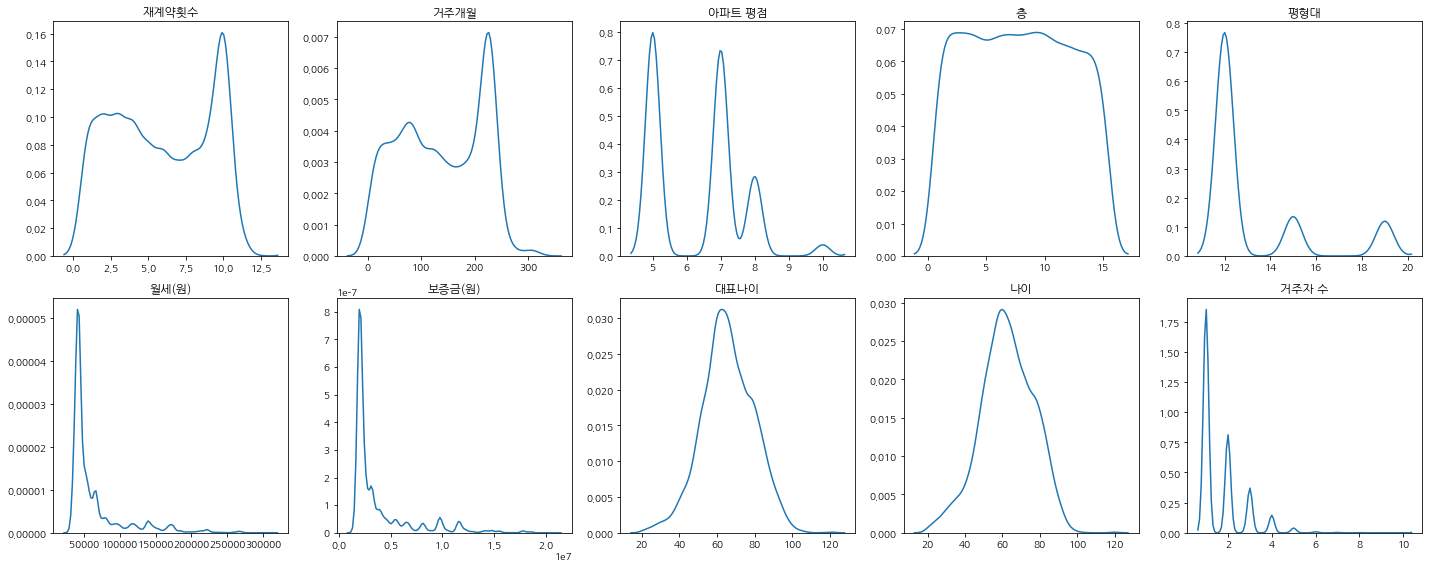

<<  명목형 변수 분포  >>


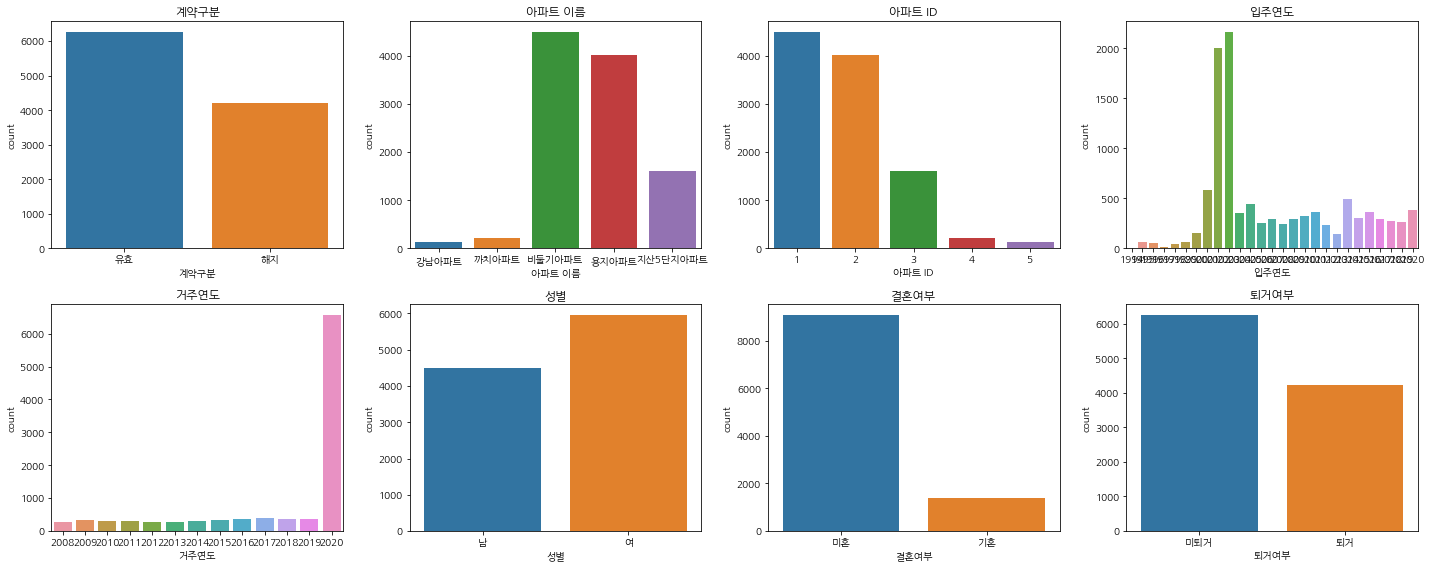

In [84]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

print("<<  연속형 변수 분포  >>")
for ax, col in zip(axes.flatten(), num_cols):
    sns.kdeplot(d1[col], ax=ax, legend=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

print("<<  명목형 변수 분포  >>")
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(d1[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

- 재계약 횟수는 10회가 가장 많은비율을 차지하며, 거주개월은 200-250사이가 가장 많음
- 아파트 아이디와 아파트 이름은 동일한 정보로 추후 아이디만 모델구축에 사용한다.
- 아파트 평점은 5>7>8>10 순으로 비율이 높음
- 아파트 층수는 1~15까지 균등함
- 평형대는 12평대가 가장 많음
- 월세, 보증금은 오른쪽으로 긴 꼬리 형태를 띄고 있음(양의 왜도)
- 대표나이, 나이는 분산이 1에 가까운 정규분포 형태를 띄고 있으며 분포 모양이 유사
- 거주자 수는 독신이 가장 많음
- 계약구분 유효가 다소 많음
- 비둘기 아파트> 용지아파트>지산5단지 아파트 주민이 대다수임
- 입주연도는 2003년도가 가장 비율이 높음
- 거주연도(2020) 비율이 가장 높음
- 여성, 미혼, 미퇴거 비율이 높음

## 1-3 이상치 처리

일단 iqr 상/하단 기준으로 확인해보고 box plot을 그려 중앙값 기준으로 각 feature간 분포를 확인해본다.

<<  연속형 변수 분포  >>


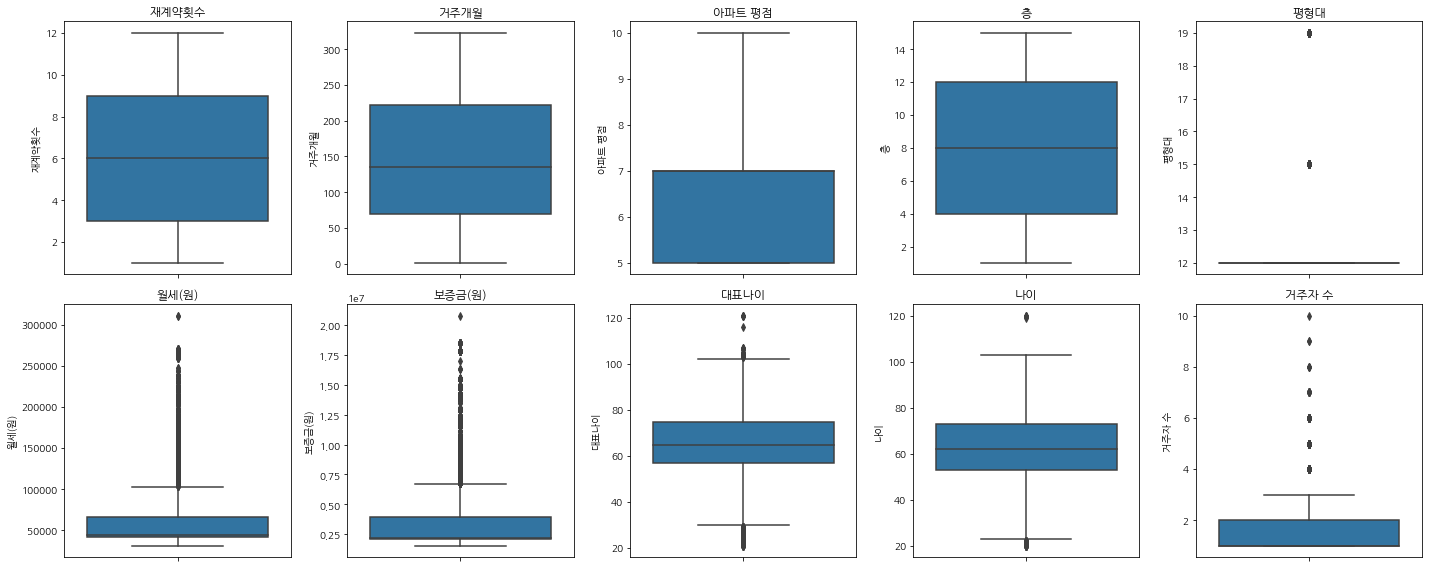

In [88]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

print("<<  연속형 변수 분포  >>")
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=d1[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [96]:
ds = d1[num_cols].describe().T

q1 = ds['25%']
q3 = ds['75%']
iqr = q3-q1
top = q3 + (1.5*iqr)
down = q1 - (1.5*iqr)

print("<<IQR 기준 상하단 이상치 수>>")
for idx in top.index:
    cnt = len(d1[(d1[idx] > top[idx]) | (d1[idx] < down[idx])])
    print(f"- {idx} ({down[idx]} ~ {top[idx]}): {cnt}")

<<IQR 기준 상하단 이상치 수>>
- 재계약횟수 (-6.0 ~ 18.0): 0
- 거주개월 (-158.0 ~ 450.0): 0
- 아파트 평점 (2.0 ~ 10.0): 0
- 층 (-8.0 ~ 24.0): 0
- 평형대 (12.0 ~ 12.0): 2609
- 월세(원) (5700.0 ~ 103300.0): 1361
- 보증금(원) (-765000.0 ~ 6747000.0): 1402
- 대표나이 (30.0 ~ 102.0): 104
- 나이 (23.0 ~ 103.0): 38
- 거주자 수 (-0.5 ~ 3.5): 631


IQR 기준으로 상하단에 포함되지 않은 이상치 개수를 확인해 보았다.  
하지만 대표나이, 나이를 제외하고는 현실세계에 있을만한 데이터이며, 해당 데이터에 대한 기반지식이 없는 상태에서 이상치로 판별하여   
삭제하는 것은 정보의 왜곡을 일으킬 수 있으므로 삭제하지 않고 활용한다.  

대표나이, 나이는 실제로 120세까지 생존하여 거주하는 인원이 있지 않을 것으므로 수집과정에서의 오류로 간주하여 iqr 범위 상단의 값을 삭제한다.

In [105]:
cnt = len(d1[(d1['나이'] > top['나이']) | (d1['대표나이'] > top['대표나이'])])
print("삭제필요 개수:", cnt)

d1 = d1[~((d1['나이'] > top['나이']) | (d1['대표나이'] > top['대표나이']))] 

삭제필요 개수: 22


## 2-1 

재계약 횟수의 중앙값을 기준으로 중앙값보다 크거나 같으면 ‘높음’, 작으면 ‘낮음’ 으로 재계약 횟수 이분 변수를 구성하시오.

In [108]:
md = d1['재계약횟수'].median()

d1['재계약수준'] = np.where(d1['재계약횟수'] >= md, "높음", "낮음")

d1['재계약수준'].value_counts()

높음    5396
낮음    5054
Name: 재계약수준, dtype: int64

재계약횟수 중앙값 기준으로 "재계약수준"이라는 이분변수를 구성하였다.   
비교적 분포가 균일하다. 

## 2-2
차원축소의 필요성을 논하고, 필요에 따라 차원을 축소하고 불필요하다면 그 근거를 논하시오.

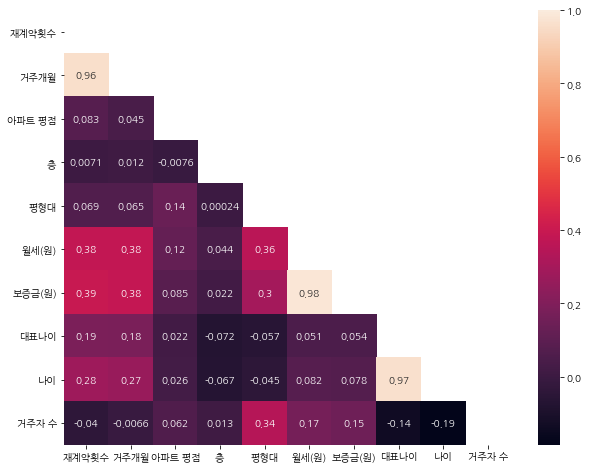

In [111]:
plt.figure(figsize=(10, 8))
corr = d1.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

수치형 변수의 1:1변수 간 선형(피어슨) 상관관계를 확인했을 시 대표나이-나이를 제외하고는 유의미한 상관관계가 식별되지 않았다. 

In [113]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame(columns=['col', 'vif'])

vif['col'] = num_cols
vif['vif'] = [variance_inflation_factor(d1[num_cols], i) for i in range(len(num_cols))]

vif

,col,vif
0,재계약횟수,67.238666
1,거주개월,61.096115
2,아파트 평점,22.204194
3,층,4.179444
4,평형대,31.984784
5,월세(원),131.611581
6,보증금(원),90.788057
7,대표나이,402.361485
8,나이,383.678924
9,거주자 수,4.897952


하지만, 1:m 변수 간 상관관계를 확인할 수 있는 VIF 확인 시 10 이상의 다중공선성으로 식별되는 변수들이 8개 식별되어  
다중공선성 제거를 위한 차원축소가 필요하다고 판단하였다. PCA 수행 시 거리에 민감하므로 스케일링을 먼저 수행 후 적용한다. 

,고윳값,분산설명력,누적분산설명력
0,177.376448,0.301076,0.301076
1,148.499864,0.211026,0.512102
2,116.487715,0.129851,0.641952
3,102.291075,0.100129,0.742081
4,100.829789,0.097288,0.839369
5,97.355931,0.090700,0.930070
6,80.450696,0.061936,0.992006
7,20.014354,0.003833,0.995839
8,17.399545,0.002897,0.998736
9,11.492519,0.001264,1.000000


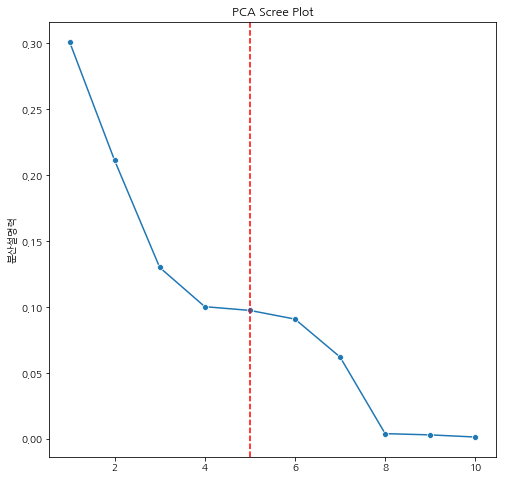

In [123]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
pca = PCA()

train = sc.fit_transform(d1[num_cols])
train = pca.fit_transform(train)

rs = pd.DataFrame({'고윳값': pca.singular_values_, 
                  "분산설명력": pca.explained_variance_ratio_, 
                  "누적분산설명력": np.cumsum(pca.explained_variance_ratio_)})

display(rs)

plt.figure(figsize=(8, 8))
sns.lineplot(data=rs, x=rs.index+1, y="분산설명력", marker='o')
plt.title("PCA Scree Plot")
plt.axvline(color='r', ls='--', x=5)
plt.show()

pca = PCA(n_components=0.8)
train = pd.DataFrame(pca.fit_transform(train), columns = ["comb"+str(i+1) for i in range(5)])                    

연속형 변수의 차원을 10-> 5차원으로 축소 시 기존 데이터의 분산을 약 83% 설명할 수 있다.   
pca 적용을 통해 재성성된 차원축 변수로 다중공선성이 제거되었다.(각 주성분 축은 직교하므로)

pca 적용은 80% 이상 분산설명력을 가진 차원축을 추후 모델링 시 column transformer를 적용하도록 한다.

In [129]:
vif = pd.DataFrame(columns=['col', 'vif'])

vif['col'] = train.columns
vif['vif'] = [variance_inflation_factor(train, i) for i in range(len(train.columns))]

vif

,col,vif
0,comb1,1.0
1,comb2,1.0
2,comb3,1.0
3,comb4,1.0
4,comb5,1.0


## 3-1
재계약 횟수 이분변수를 기준으로 세그먼트를 구분하고 각 세그먼트의 특징을 분석하시오.

<<수치형 변수별 재계약 수준 분포확인>>


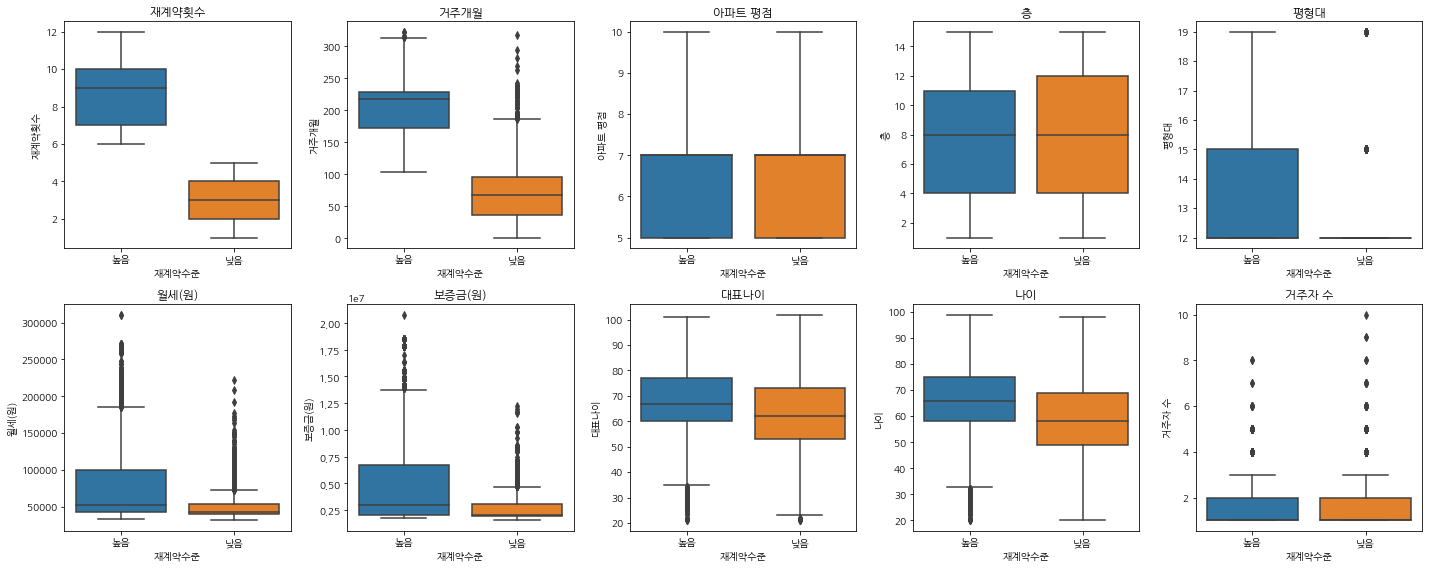

In [132]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

print("<<수치형 변수별 재계약 수준 분포확인>>")
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=d1[col], x=d1['재계약수준'], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

재계약 수준변수는 재계약 횟수의 중앙값인 6회 이상이면 "높음", 미만이면 "낮음"으로 정의된 이분변수이다.  

재계약 횟수, 거주개월, 대표나이, 나이는 재계약수준이 높은 경우가 크며,  
월세와 보증금, 평형대도 마찬가지로 높은 경우가 높으나 낮음에 비해 분포범위가 넓다.  
아파트평점, 거주자수는 차이가 없다.  

재계약수준이 낮은 경우 아파트 평형은 낮은평수인 12평에 집중되어 있다. 

<<  명목형 변수 분포  >>


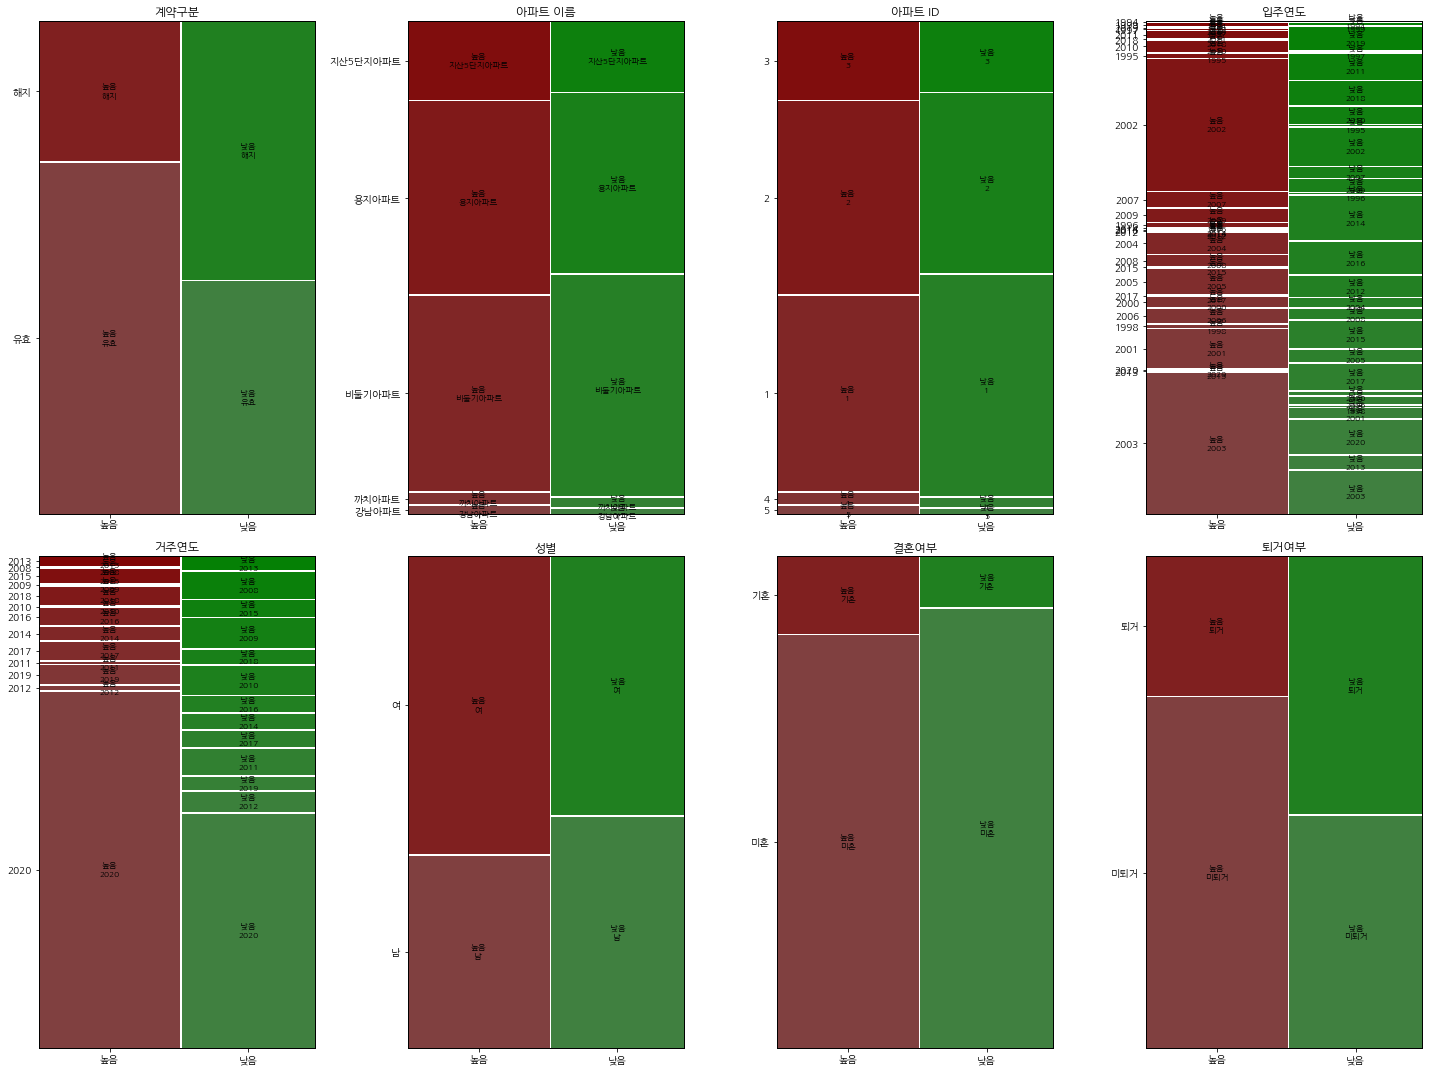

In [136]:
from statsmodels.graphics.mosaicplot import mosaic


fig, axes = plt.subplots(2, 4, figsize=(20, 15))

print("<<  명목형 변수 분포  >>")
for ax, col in zip(axes.flatten(), cat_cols):
    mosaic(d1, ["재계약수준", col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

- 재계약 수준이 높은 경우 계약구분 유효, 미퇴거 비율이 높음
- 높음은 비둘기아파트, 용지아파트 거주비율이 비슷하게 높으며, 낮음은 비둘기아파트 비율이 더 높다. 
- 두 세그먼드 모두 여자, 미혼 비율이 높다.(다만, 높음의 경우 여성비율이 더 높으며, 낮음의 경우 미혼 비율이 더 높음)
- 높음의 경우 2002, 2003년 입주년도 비율이 높음
- 높음의 경우 현재(2020) 거주중인 비율이 높음

## 3-2
재계약횟수 변수를 종속변수로 하는 회귀 분석을 두 가지 이상의 방법론을 통해 수행하고 최종 모델을 결정하시오. 재계약횟수 이분변수를 종속변수로 하는 분류 분석을 두가지 이상의 방법론을 통해 수행하고 최종 모델을 결정하시오.

<회귀모델>
- SVM: 서포트벡터를 활용한 회귀모델
- Randomforest: 배깅 기반 앙상블 모델, 여기서는 회귀모델 사용

<분류모델>
- LGBM: 속도와 정확도를 모두 고려한 트리 기반 머신러닝 알고리즘
- Randomforest: 배깅 기반 앙상블 모델, 여기서는 분류모델 모두 사용

회귀모델의 경우 rmse로 성능을 평가, 분류모델의 경우 두 클래스의 비율이 비슷하므로 accuracy 사용

In [144]:
#회귀분석

from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

Y = d1['재계약횟수']
#정보가 중복되는 컬럼 삭제
x_cols = ['계약구분', '거주개월', '아파트 평점', '층', '평형대', '입주연도', 
          '거주연도', '월세(원)', '보증금(원)', '대표나이', '나이', '성별', '결혼여부', '거주자 수']
X = d1[x_cols]

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=42)

num_cols = train_X.select_dtypes('number').columns
cat_cols = train_X.select_dtypes('object').columns

#스케일링->PCA
num_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.8))
])

# one-hot encoding
cat_pipeline = Pipeline([
    ('one-hot', OneHotEncoder(sparse=False))
])

#컬럼트랜스포머
preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_pipeline, num_cols), 
        ('cat', cat_pipeline, cat_cols)
    ]
)

svr = Pipeline([
    ('preprocesor', preprocessor), 
    ('regressor', SVR())
])

rfr = Pipeline([
    ('preprocesor', preprocessor), 
    ('regressor', RandomForestRegressor())
])


model_list = [('SVR', svr), ('Random forest rs', rfr)]
dt_list = [('train', train_X, train_Y), ('test', test_X, test_Y)]

rs = pd.DataFrame(columns=['name', 'data', 'mse', 'rmse', 'r2'])

for m_name, model in model_list:
    model.fit(train_X, train_Y)
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        r2 = r2_score(y, pred)
        mse = mean_squared_error(y, pred)
        rmse = np.sqrt(mse)
        rs.loc[len(rs)] = [m_name, d_name, mse, rmse, r2]
display(rs)

,name,data,mse,rmse,r2
0,SVR,train,0.589939,0.768075,0.942807
1,SVR,test,0.675657,0.821983,0.934379
2,Random forest rs,train,0.152514,0.390531,0.985214
3,Random forest rs,test,1.084057,1.041181,0.894715


두 회귀모델의 성능을 r2, mse, rmse로 비교해보았다.  
모델의 설명력은 SVR의 경우 학습/테스트셋에서 0.93~0.94 정도로 균일함을 보이고 있으며, 높은 설명력을 가진다.
mse, rmse도 두 데이터셋에서 균일한 성능을 보여주고 있다.  

랜덤 포레스트 회귀모델은 train set에서는 svr보다 준수한 성능을 보이지만, test set에서는 보다 높은 오차, 설명력 저하를 보이므로  
train set에 모델이 지나치게 적합된 과적합을 보인다고 할 수 있다.  
따라서 svr을 채택한다. 

In [220]:
# 분류분석
import time 

Y = np.where(d1['재계약수준'] == '높음', 1, 0)
#정보가 중복되는 컬럼 삭제
x_cols = ['계약구분', '거주개월', '아파트 평점', '층', '평형대', '입주연도', 
          '거주연도', '월세(원)', '보증금(원)', '대표나이', '나이', '성별', '결혼여부', '거주자 수']
X = d1[x_cols]

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=42)

num_cols = train_X.select_dtypes('number').columns
cat_cols = train_X.select_dtypes('object').columns


lgbm = Pipeline([
    ('preprocesor', preprocessor), 
    ('classifier', LGBMClassifier(random_state=42))
])

rf = Pipeline([
    ('preprocesor', preprocessor), 
    ('classifier', RandomForestClassifier(random_state=42))
])


model_list = [('lgbm', lgbm), ('Random forest class', rf)]
dt_list = [('train', train_X, train_Y), ('test', test_X, test_Y)]

rs = pd.DataFrame(columns=['name', 'data', 'accuracy_score', 'time'])

for m_name, model in model_list:
    start = time.time()
    model.fit(train_X, train_Y)
    end = time.time()
    t_time = end - start
    print(f"<<  {m_name}  >>")
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        score = accuracy_score(y, pred)
        rs.loc[len(rs)] = [m_name, d_name, score, t_time]
        print(f"- 데이터셋: {d_name} - ")
        print(classification_report(y, pred))
display(rs)

<<  lgbm  >>
- 데이터셋: train - 
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3822
           1       0.98      1.00      0.99      4015

    accuracy                           0.99      7837
   macro avg       0.99      0.99      0.99      7837
weighted avg       0.99      0.99      0.99      7837

- 데이터셋: test - 
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1232
           1       0.95      0.97      0.96      1381

    accuracy                           0.96      2613
   macro avg       0.96      0.95      0.96      2613
weighted avg       0.96      0.96      0.96      2613

<<  Random forest class  >>
- 데이터셋: train - 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3822
           1       1.00      1.00      1.00      4015

    accuracy                           1.00      7837
   macro avg       1.00      1.00    

,name,data,accuracy_score,time
0,lgbm,train,0.989409,0.492455
1,lgbm,test,0.955607,0.492455
2,Random forest class,train,1.000000,1.454075
3,Random forest class,test,0.952545,1.454075


test set의 accuracy를 기준으로 하였을 때, lgbm의 정확도가 더 높으며, 모델학습시간도 더 짧으므로 lgbm을 최적의 모델로 선정  
두 모델 모두 두 데이터셋에서 과적합 없이 준수한 성능을 보여주고 있다.

## 3-3
최종 채택한 모델에서 각각 유의하게 작용하는 변수를 확인 하고 설명하시오

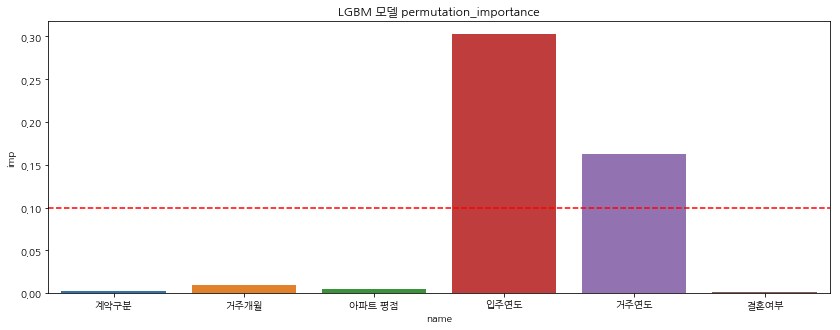

In [221]:
from sklearn.inspection import permutation_importance

f_imp = permutation_importance(lgbm, test_X, test_Y, n_repeats=10, random_state=42)

feats = train_X.columns
f_importance = f_imp.importances_mean

f_imp_df = pd.DataFrame({'name': feats, "imp": f_importance})
f_imp_df = f_imp_df.loc[f_imp_df['imp'] > 0]

plt.figure(figsize= (14, 5))

sns.barplot(data=f_imp_df, x='name', y='imp')
plt.axhline(y=0.1, color='r', linestyle='--') #변수중요도가 10% 이상인 변수만 사용
plt.title('LGBM 모델 permutation_importance')
plt.show()

특정 피처의 값을 무작위로 섞어 모델 성능 감소 정도로 중요도 측정하는 permutation_importance를 확인했을 시  
입주연도와 거주연도가 모델성능에 큰 영향을 주는 것으로 확인되었다.  

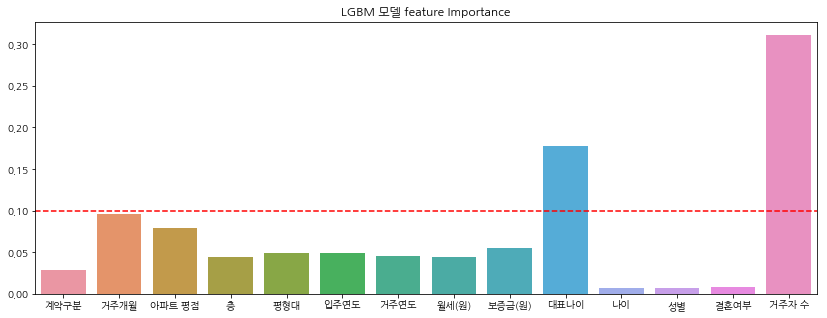

In [226]:
import re

pca_param = lgbm.named_steps['preprocesor'].transformers_[0][1]['pca'].components_ #pca 계수: 9->5차원으로 축소
lgbm_imp = lgbm.named_steps['classifier'].feature_importances_ #7차원(범주형 변수 sex 추가)

#one-hot 인코딩 변수 중요도 복원
ohe_feature_names = lgbm.named_steps['preprocesor'].transformers_[1][1].named_steps['one-hot'].get_feature_names(cat_cols)
cat_orig_vars = [re.sub(r'(_[^_]+)$', '', name) for name in ohe_feature_names]

cat_importances = lgbm_imp[5:]  # pca 축소 후 주성분 개수 이후부터 범주형 dummy 중요도

#각 변수별 중요도 집계
cat_df = pd.DataFrame({
    'original_var': cat_orig_vars,
    'importance': cat_importances
})
#원 변수별 중요도 합산
cat_importance_sum = cat_df.groupby('original_var')['importance'].sum() 


# # 3. 전환 행렬: (k, m) * (k, 1) → (m,)
# #    각 원본feature의 importance = sum over PC [ (주성분 importance × loading^2) ]
original_imp = np.sum((pca_param**2) * lgbm_imp[:5][:, np.newaxis], axis=0)
original_imp= np.append(original_imp, cat_importance_sum.values) #카테고리 추가

f_name = X.columns

plt.figure(figsize=(14, 5))
sns.barplot(x=f_name, y=original_imp/sum(original_imp))
plt.title('LGBM 모델 feature Importance')
plt.axhline(y=0.1, color='r', linestyle='--') #변수중요도가 10% 이상인 변수만 사용
plt.show()

트리 학습 시 분할할 때 불순도 감소량으로 각 피처 중요도 계산하는 방식으로 모델의 feature 중요도를 계산하였을 시  
거주자수, 대표나이가 중요변수로 판별되었다.

## 3-4
해당 데이터 분석결과로 얻을 수 있는 점 제시

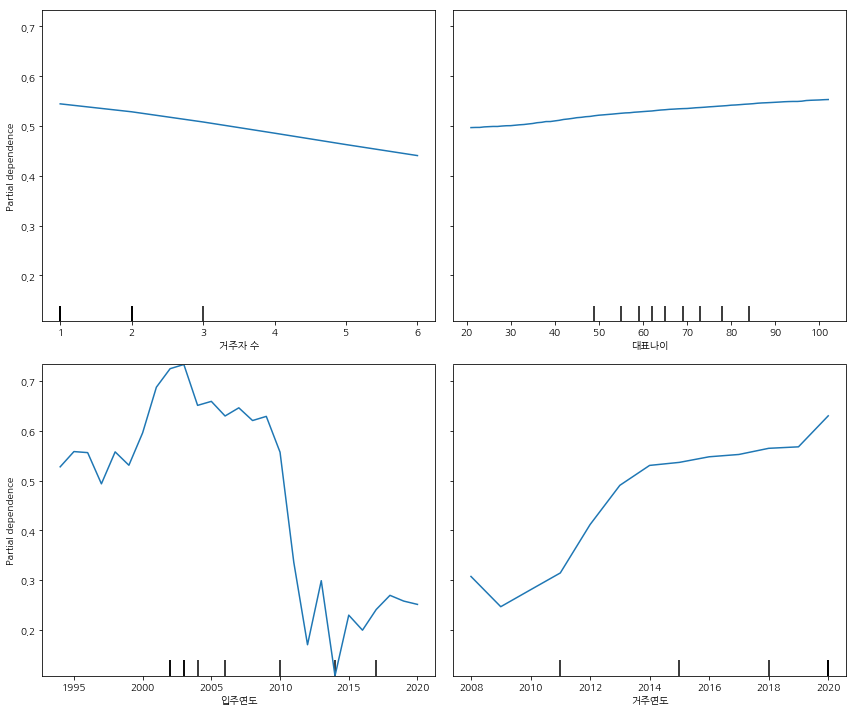

In [225]:
from sklearn.inspection import partial_dependence
from sklearn.inspection import plot_partial_dependence


s_col = ['거주자 수', '대표나이', '입주연도', '거주연도']

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

plot_partial_dependence(estimator=rf, 
                       X=test_X, 
                       features=s_col, 
                       percentiles=(0, 1), 
                       ax = ax)
plt.tight_layout()
plt.show()

- 거주자수가 늘어날수록 재계약 수준은 낮아짐
- 대표나이가 올라갈수록 재계약 수준은 높아짐
- 입주연도가 2010년 이전일 경우 재계약 수준이 높으며, 이후로는 낮아짐
- 거주연도가 길어질수록 재계약 수준은 높아짐

거주자 수가 낮으며, 나이가 많고, 입주기간이 길며, 거주연도가 최신으로 갱신될 수록 재계약 수준은 높아짐

## 4-1

각 회차별로 1번 타자의 출루 (1,2,3루타와 사사구(볼넷, 몸에맞는공))가 있는 경우에 대해 득점이 발생 했는지 확인하고자 한다.   
이를 위한 전처리를 수행하라. (단, 첫 번째 혹은 두 번째 타자가 홈런을 친 경우 해당 회차 데이터는 제외한다.)

- 데이터 출처 : https://www.kaggle.com/datasets/pschale/mlb-pitch-data-20152018 데이터를 후처리
- 데이터 링크 : https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/29/p2_.csv

- 데이터 설명 :

A 야구구단의 시합 결과중 일부를 나타낸다. 각 행은 하나의 경기를 의미(game_id)하며 9회차(= 9이닝) 동안 1번타자, 2번타자의 출루   
정보를 의미한다. 각 컬럼에 대한 설명은 아래 이미지와 같으며, value값의 index는 이미지의 ‘수치 의미’ 열을 통해 확인 할 수 있다.

경기 당 9이닝 동안 1번 타자, 2번 타자의 출루 정보를 기록한 데이터입니다.

- 1: 1루타
- 2: 2루타
- 3: 3루타
- 4: 홈런
- 5: 삼진 제외 모든 아웃
- 6: 볼넷
- 7: 삼진
- 8: 몸에 맞는 공
- 9: 희생 번트

In [2]:
d4= pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/29/p2_.csv')
d4.head(2)

,game_id,a1_1,a1_2,a2_1,a2_2,a3_1,a3_2,a4_1,a4_2,a5_1,...,a9_2,b1,b2,b3,b4,b5,b6,b7,b8,b9
0,201900016,5,5,5,5,5,5,5,5,5,...,5,0,0,0,0,0,0,0,4,2
1,201900023,6,4,5,5,2,5,1,1,6,...,7,3,0,0,1,0,1,3,1,0


In [3]:
d4.isna().sum() #결측치는 없음

game_id    0
a1_1       0
a1_2       0
a2_1       0
a2_2       0
a3_1       0
a3_2       0
a4_1       0
a4_2       0
a5_1       0
a5_2       0
a6_1       0
a6_2       0
a7_1       0
a7_2       0
a8_1       0
a8_2       0
a9_1       0
a9_2       0
b1         0
b2         0
b3         0
b4         0
b5         0
b6         0
b7         0
b8         0
b9         0
dtype: int64

In [4]:
e_cols = d4.select_dtypes('object').columns

for col in e_cols:
    display(d4[col].value_counts())

5    92
7    35
1    29
     12
2    10
6    10
4    10
8     2
Name: a1_1, dtype: int64

5     87
7     47
1     30
6     14
4     11
2      9
 :     2
Name: a2_1, dtype: int64

5    95
7    29
1    26
6    25
2    10
4     6
&     5
8     3
3     1
Name: a4_1, dtype: int64

5    68
7    43
1    29
6    22
2    20
4    11
"     3
8     2
3     2
Name: a7_1, dtype: int64

모두 수치형 변수여야 하나 object 형 4개 변수가 식별되었고, 데이터 입력과정에서의 오류로 식별되는 문자열(공백,  :, &, ")을 포함한  
값이 일부 식별되었다. 전체 데이터 대비 큰 비중을 차지하지 않으며, 적절한 보간값이 없으므로 삭제해준다. 

In [5]:
d4 = d4[~d4[e_cols].isin([' :', '&', '"', ' ']).any(axis=1)]
d4[e_cols] = d4[e_cols].astype("int64")

In [6]:
s1_cols = [col for col in d4.columns if '_1' in col]
s2_cols = [col for col in d4.columns if '_2' in col]
b_cols = [col for col in d4.columns if 'b' in col]

#첫번째 선수 melt 
s1 = d4.melt(id_vars='game_id',  #아이디 인덱스
            value_vars=s1_cols, #값으로 쓰일 컬럼지정
            var_name = 'no', #컬럼명
            value_name='action1', #값 컬럼명
            ignore_index=False)

s2 = d4.melt(id_vars='game_id', 
            value_vars=s2_cols, 
            var_name = 'no', #이닝 정보만 남게
            value_name='action2', 
            ignore_index=False)

score = d4.melt(id_vars='game_id', 
            value_vars=b_cols, 
            var_name = 'no', #이닝 정보만 남게
            value_name='score', 
            ignore_index=False)


s1['no'] = [s.split('_')[0][-1] for s in s1['no']] #이닝정보만 추출
s2['no'] = [s.split('_')[0][-1] for s in s2['no']] #이닝정보만 추출
score['no'] = [s[1] for s in score['no']] #이닝정보만 추출

rs = pd.merge(s1, s2, how='inner', on=['game_id', 'no'])
rs = pd.merge(rs, score, how='inner', on=['game_id', 'no'])

rs

,game_id,no,action1,action2,score
0,201900016,1,5,5,0
1,201900023,1,6,4,3
2,201900103,1,5,6,0
3,201900112,1,5,7,0
4,201900131,1,5,1,0
...,...,...,...,...,...
1615,201902327,9,7,5,0
1616,201902346,9,6,1,1
1617,201902365,9,1,9,2
1618,201902392,9,4,7,1


여기서 조건에 따른 가공을 해 준다. 

- 각 회차별로 1번 타자의 출루 (1,2,3루타와 사사구(볼넷, 몸에맞는공))가 있는 경우 데이터만 남김(1, 2, 3, 6, 8)
- 단, 첫 번째 혹은 두 번째 타자가 홈런을 친 경우 해당 회차 데이터는 제외(action 1, 2에서 4인 값 삭제)

In [7]:
rs = rs[rs['action1'].isin([1, 2, 3, 6, 8])].reset_index(drop=True) #해당 데이터만 남김
rs = rs[~((rs['action1'] == 4) | (rs['action2'] == 4))]
len(rs)

480

In [8]:
# 득점 여부에 대한 판별문제이므로 득점여부 이진 변수 추가
rs['is_score'] = np.where(rs['score'] > 0, 1, 0)

## 4-2
4-1 데이터에 대해 Logistic Regression을 적용하고 2번타자의 희생번트 여부에 대한 회귀 계수 검정을 하라.

<가설설정>
- 귀무: 2번 타자의 희생번트 회귀계수는 0이다.
- 대립; 2번 타자의 희생번트 회귀계수는 0이 아니다.

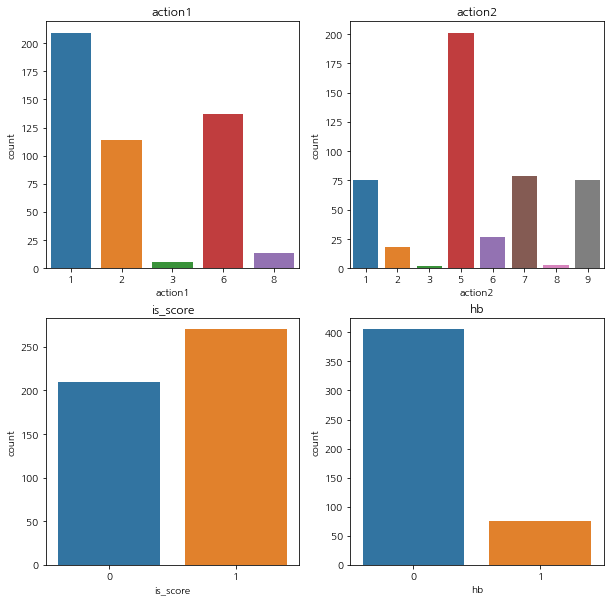

In [9]:
rs['hb'] = np.where(rs['action2'] == 9, 1, 0)
rs.head(3)

# 각 사용 설명변수별 count plot
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for col, ax in zip(['action1', 'action2', 'is_score', 'hb'], axes.flatten()):
    sns.countplot(rs[col], ax=ax)
    ax.set_title(col)
plt.show()

2번 타자의 희생번트 여부에 따른 이진 파생변수를 생성 후 class를 비교하였을 시 희생번트가 아닌 클래스의 비율이 확연히 높았다.  
이를 통해 불균형 데이터 처리를 해야 함을 파악할 수 있다. 

In [12]:
# 로지스틱 모델 적합
import statsmodels.formula.api as smf

model = smf.logit('is_score~C(action1)+C(action2)', data=rs).fit() #actor2와 hb의 정보가 중복되므로 action2는 사용x, score도 뺌

display(model.summary())

         Current function value: 0.602946
         Iterations: 35


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               is_score   No. Observations:                  480
Model:                          Logit   Df Residuals:                      468
Method:                           MLE   Df Model:                           11
Date:                Sat, 30 Aug 2025   Pseudo R-squ.:                  0.1202
Time:                        11:17:18   Log-Likelihood:                -289.41
converged:                      False   LL-Null:                       -328.95
Covariance Type:            nonrobust   LLR p-value:                 2.229e-12
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.2245      0.309      3.958      0.000       0.618       1.831
C(action1)[T.2]     0.4272      0.257      1.662      0.097      -0.077       0.931
C(action1)[T.3]     1.9006      1.147      1.657      0.097      -0.347       4.149
C(action1)[T.6]     0.1530      0.242      0.633      0.527      -0.321       0.627
C(action1)[T.8]    -0.4362      0.592     -0.737      0.461      -1.596       0.724
C(action2)[T.2]     1.4563      1.070      1.361      0.173      -0.641       3.553
C(action2)[T.3]    18.0363   1.12e+04      0.002      0.999   -2.19e+04    2.19e+04
C(action2)[T.5]    -1.5287      0.325     -4.711      0.000      -2.165      -0.893
C(action2)[T.6]    -0.3474      0.529     -0.657      0.511      -1.384       0.689
C(action2)[T.7]    -2.1867      0.380     -5.752      0.000      -2.932      -1.442
C(action2)[T.8]    -0.8644      1.266     -0.683      0.495      -3.346       1.617
C(action2)[T.9]    -0.5372      0.385     -1.396      0.163      -1.292       0.217
===================================================================================
"""

유의수준 5% 하에서  
- 모델의 설명력(Pseudo R-squ.:0.1202): 낮음
- df: 5로 11개의 변수가 사용됨
- 로그우도비 검정결과는 LLR p-value:2.229e-12로 해당 모델이 null model보다 통계적으로 유의함
- 2번 타자의 희생번트 유무 변수의 회귀계수는 p-value 	0.163로 귀무가설을 기각할 수 없음.

## 4-3
SMOTE (random_state =0 지정)를 적용하여 data imbalance를 해결하라

In [16]:
from imblearn.over_sampling import SMOTE
from collections import Counter

Y = rs['is_score']
X = rs[['action1', 'action2']]

# 데이터 7:3분할
from sklearn.model_selection import train_test_split

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, test_size=0.3, random_state=0)

#리샘플링
smt = SMOTE(random_state=0)
train_X, train_Y = smt.fit_resample(train_X, train_Y)
print(f"각 레이블 갯수: {Counter(train_Y)}")

각 레이블 갯수: Counter({0: 182, 1: 182})


smote를 이용하여 oversampling 결과 동일한 비율의 클래스를 유지

## 4-4
4-3 구성 데이터에 Logistic Regression을 적용하고 결과를 분석하라

In [17]:
from statsmodels.tools import tools

# train_X를 DataFrame으로 변환 및 category 타입으로 설정
train_X = pd.DataFrame(train_X, columns=['action1', 'action2']).astype('category')

# train_Y를 Series로 변환 (컬럼명 지정)
train_Y = pd.Series(train_Y, name='is_score')

# 합치기
train = pd.concat([train_X, train_Y], axis=1)

# 테스트도
test_X = pd.DataFrame(test_X, columns=['action1', 'action2']).astype('category')
test_Y = pd.Series(test_Y, name='is_score')
test = pd.concat([test_X, test_Y], axis=1)

# 로지스틱 회귀 (data 인자를 train으로 수정)
model2 = smf.logit('is_score ~ C(action1) + C(action2)', data=train).fit()

display(model2.summary())

Optimization terminated successfully.
         Current function value: 0.596820
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               is_score   No. Observations:                  364
Model:                          Logit   Df Residuals:                      352
Method:                           MLE   Df Model:                           11
Date:                Sat, 30 Aug 2025   Pseudo R-squ.:                  0.1390
Time:                        11:26:42   Log-Likelihood:                -217.24
converged:                       True   LL-Null:                       -252.31
Covariance Type:            nonrobust   LLR p-value:                 1.156e-10
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           1.2045      0.361      3.337      0.001       0.497       1.912
C(action1)[T.2]     0.3820      0.302      1.263      0.207      -0.211       0.975
C(action1)[T.3]     1.1822      1.352      0.874      0.382      -1.468       3.832
C(action1)[T.6]     0.3149      0.280      1.125      0.261      -0.234       0.864
C(action1)[T.8]    -0.6341      0.698     -0.908      0.364      -2.002       0.734
C(action2)[T.2]     0.9206      1.103      0.834      0.404      -1.242       3.083
C(action2)[T.3]    -0.7177      1.277     -0.562      0.574      -3.220       1.785
C(action2)[T.5]    -1.8938      0.377     -5.023      0.000      -2.633      -1.155
C(action2)[T.6]    -0.5890      0.600     -0.982      0.326      -1.764       0.586
C(action2)[T.7]    -2.5334      0.466     -5.432      0.000      -3.448      -1.619
C(action2)[T.8]    -0.8708      1.278     -0.682      0.496      -3.375       1.634
C(action2)[T.9]    -0.6632      0.442     -1.499      0.134      -1.530       0.204
===================================================================================
"""

모델의 설명력이 미세하게 상승하였음. 우도비 검정결과 LLR p-value:	1.156e-10 로 통계적으로 유의한 모델 

In [371]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

dt_list = [('train', train_X, train_Y), ('test', test_X, test_Y)]

rs = pd.DataFrame(columns=['name', 'accuracy', 'f1'])

for name, x, y in dt_list:
    pred = np.where(model2.predict(x) >= 0.5, 1, 0)
    score = accuracy_score(y, pred)
    f1 = f1_score(y, pred)
    rs.loc[len(rs)] = [name, score, f1]
    print(f"-- 데이터셋: {name} --")
    print(classification_report(y, pred))
display(rs)

-- 데이터셋: train --
              precision    recall  f1-score   support

           0       0.58      0.46      0.52       182
           1       0.55      0.67      0.61       182

    accuracy                           0.57       364
   macro avg       0.57      0.57      0.56       364
weighted avg       0.57      0.57      0.56       364

-- 데이터셋: test --
              precision    recall  f1-score   support

           0       0.39      0.38      0.38        56
           1       0.61      0.62      0.62        88

    accuracy                           0.53       144
   macro avg       0.50      0.50      0.50       144
weighted avg       0.52      0.53      0.53       144



,name,accuracy,f1
0,train,0.565934,0.606965
1,test,0.527778,0.617978


예측결과를 볼 때 train/test set 모두 낮은 예측결과를 보이고 있으며, 과적합은 없다.   
원본데이터의 레이블 0(득점을 못했을 경우)의 데이터 수가 더 적었는데, 성능지표가 레이블 1보다 전반적으로 낮게 측정되었다.   
- precision, recall, f1_socre

다음은 각 변수의 오즈비 계산

In [18]:
# 오즈비 계산
odds_ratios = np.exp(model2.params)

# 결과를 DataFrame으로 보기 좋게 출력
odds_df = pd.DataFrame({
    'Feature': model2.params.index,
    'Coefficient': model2.params,
    '오즈비': odds_ratios
})

display(odds_df)

,Feature,Coefficient,오즈비
Intercept,Intercept,1.204498,3.335086
C(action1)[T.2],C(action1)[T.2],0.381995,1.465205
C(action1)[T.3],C(action1)[T.3],1.182223,3.261616
C(action1)[T.6],C(action1)[T.6],0.314873,1.370086
C(action1)[T.8],C(action1)[T.8],-0.634074,0.530427
C(action2)[T.2],C(action2)[T.2],0.920620,2.510847
C(action2)[T.3],C(action2)[T.3],-0.717724,0.487861
C(action2)[T.5],C(action2)[T.5],-1.893758,0.150505
C(action2)[T.6],C(action2)[T.6],-0.588989,0.554888
C(action2)[T.7],C(action2)[T.7],-2.533437,0.079386


- 1번 선수가 1루타일 때와 비교해서 2루타일 경우의 발생 오즈가 약 46% 증가 - 유의x
- 1번 선수가 1루타일 때와 비교해서 3루타일 경우의 발생 오즈가 약 262% 증가 - 유의x
- 1번 선수가 1루타일 때와 비교해서 볼넷일 경우의 발생 오즈가 약 37% 증가 - 유의x
- 1번 선수가 1루타일 때와 비교해서 몸에 맞는 공일 경우의 발생 오즈가 약 74% 감소 - 유의x  
유의할 경우 이런식으로 오즈비 계산 수행

## 5
제품 A의 불량률은 0.03이다. 25개의 제품을 뽑았을 때 3개가 불량일 확률을 구하시오. (소수점 다섯 째 자리에서 반올림)

불량과 양품 두 가지의 선택지를 가진 베르누이 시행을 여러번 반복했을 경우인 이항분포 문제이다. 

In [252]:
from scipy.stats import binom

r = 0.03
n = 25
k = 3

p = binom.pmf(k, n, r) #뽑은 개수, 전체수, 확률

print(f" 25개의 제품을 뽑았을 때 3개가 불량일 확률: {p:.4f}")

 25개의 제품을 뽑았을 때 3개가 불량일 확률: 0.0318


## 6
C사 생산 제품 1000개 중 양품이 600개, D사 생산 제품 500개 중 양품이 200개 이다. 두 회사의 양품률에 차이가 있는지 검정하여라.

이 문제는 두 회사의 양품률의 차이에 대한 검정으로 비율검정 문제이며, 각각의 데이터가 충분히 크므로 중심극한의 정리에 의해  
z검정으로 해결할 수 있다. 

유의수준 5% 하에서 z검정을 실시하여 두 그룹의 양품률 차이를 검정한다. (양측검정)

<가설설정>
- H0: 두 회사의 양품률은 차이가 없다. 
- H1: 두 회사의 양품률은 차이가 있다.

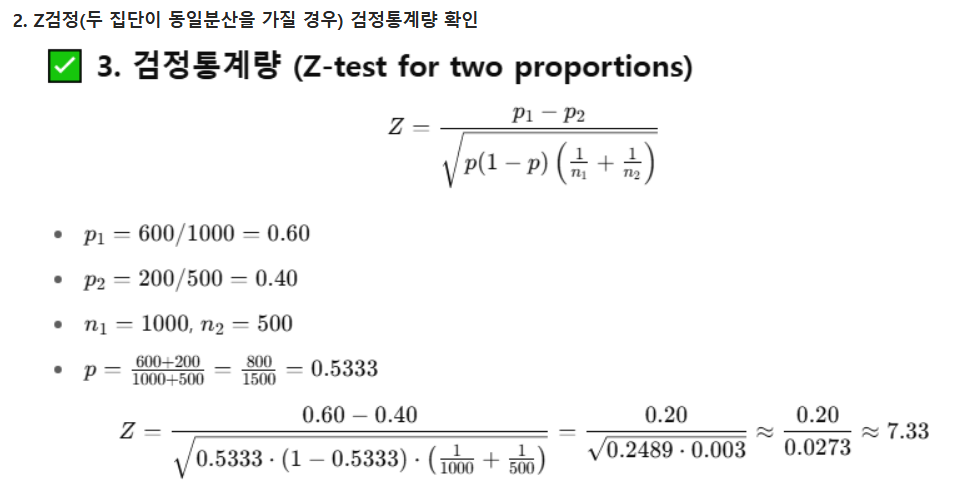

In [250]:
from scipy.stats import norm

c = 600/1000 #c사 양품률
d = 200/500 # d사 양품률
p = (600+200)/(1000+500) #전체 양품률

z_score = (c-d) / np.sqrt(p*(1-p)*((1/1000)+(1/500)))

p_value = 2*(1-norm.cdf(abs(z_score)))

print(f"z 검정통계량: {z_score}")
print(f"양품률 비교: {c} / {d}")
print(f"p-value: {p_value} / 귀무가설", "기각" if p_value < 0.05 else "채택")

z 검정통계량: 7.319250547113997
양품률 비교: 0.6 / 0.4
p-value: 2.4935609133081016e-13 / 귀무가설 기각


p-value가 충분히 작으므로 귀무가설을 기각한다.  따라서 두 회사의 양품률은 차이가 있다. 

## 7-1
각 차종 별 범퍼 파손의 정도에 차이가 유의한지 검정하라.  

데이터 설명 : 아래 데이터는 a,b,c,d 네 차종 각각 5회 실험 시 범퍼 파손 정도 이다.   
(단, 각 모집단은 정규분포를 따르며 모집단 간 등분산성을 가정한다.)

- 데이터 url : https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/29/p7.csv

In [227]:
d7 = pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/29/p7.csv')
d7.head()

,name,ratio
0,A,10.993428
1,A,9.723471
2,A,11.295377
3,A,13.046060
4,A,9.531693


수집된 데이터이므로 독립성이 보장된다는 가정 하에 정규분포, 등분산성이 가정되어 있으므로 모수검정을 실시할 수 있다.  
해당 데이터의 설명변수는 name으로 명목형 변수이며, 4개의 그룹이며,  종속변수는 연속형 변수이므로  
F통계량을 사용하여 각 그룹간 데이터의 분산을 비교하는 one-way anova를 실시할 수 있다. 신뢰구간 95%, 유의수준 5% 하에서 검정을 실시한다.

<가설설정>
- H0: 각 차종별 범퍼 파손의 차이는 없다.
- H1: 하나의 차종이라도 범퍼 파손의 차이가 있다. 

In [229]:
import statsmodels.stats.api as sm
import statsmodels.formula.api as smf

model = smf.ols(formula='ratio~C(name)', data=d7).fit()

one_anova = sm.anova_lm(model, typ=2)

display(one_anova)

,sum_sq,df,F,PR(>F)
C(name),236.534027,3.0,24.976953,0.000003
Residual,50.507154,16.0,NaN,NaN


검정결과, p-value가 0.000003로 0.05보다 작으므로 귀무가설을 기각한다.  
따라서, 하나의 차종이라도 범퍼 파손의 차이가 있다는 대립가설은 통계적으로 유의하다. 

## 7-2
귀무가설을 채택한다면 그 의미를 해석하고, 귀무가설을 기각하였다면 사후분석을 시행하라.¶

귀무가설을 기각하므로 사후분석을 실시한다. Tukey's HSD (사후 분석)를 실시하여 어느 쌍에서 통계적으로 유의한지 확인한다.

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B   5.3934  0.001   2.1785  8.6083   True
     A      C  -4.2156 0.0085  -7.4305 -1.0007   True
     A      D  -0.7086 0.9207  -3.9235  2.5063  False
     B      C   -9.609    0.0 -12.8239 -6.3941   True
     B      D   -6.102 0.0003  -9.3169 -2.8871   True
     C      D    3.507 0.0302   0.2921  6.7219   True
-----------------------------------------------------
Figure(720x432)


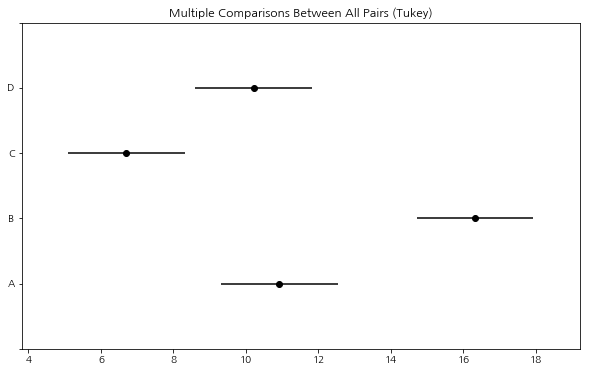

In [238]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

rs = pairwise_tukeyhsd(endog=d7['ratio'], groups=d7['name'], alpha=0.05)

print(rs)

print(rs.plot_simultaneous())

A-D 차종 간 범퍼파손의 차이는 없다.(p-value: 0.0085로 귀무가설 기각 불가)  
나머지 차종 쌍 간에는 범퍼파손의 차이가 있으며, 이 차이는 통계적으로 유의하다.  
C-B간 차이가 가장 많이 나며, C사의 범퍼파손 정도가 가장 낮고, B사의 파손정도가 가장 높다.

## 8
L1,L2,L3 세 개의 생산라인에서 각각 13%, 37%, 50%를 생산하며 각각 1.1% , 2.1%, 3.3% 불량률을 갖는다.   
불량 제품이 나왔을 때 L1 라인에서 생산되었을 확률을 구하시오. (소수점 둘째자리에서 반올림)

P(L1|불량)을 구하는 문제로 베이즈 정리를 통해 해결할 수 있다.  
P(L1|불량) = P(불량|L1)*p(L1) / P(불량)

In [2]:
l1_m = 0.13
l2_m = 0.37
l3_m = 0.5

l1_e = 0.011
l2_e = 0.021
l3_e = 0.033


total_e = (l1_m*l1_e) + (l2_m*l2_e) + (l3_m*l3_e) #전체 불량률
e_l1 = (l1_m*l1_e)/l1_m #l1일때 불량률 l1_e와 동일함

ans = round((e_l1*l1_m)/total_e, 1)

print(f"- 전체 불량률: {total_e}")
print(f"- L1일 때 불량률: {e_l1}")
print(f"- 불량 제품이 나왔을 때 L1 라인에서 생산되었을 확률: {ans}")

- 전체 불량률: 0.0257
- L1일 때 불량률: 0.011
- 불량 제품이 나왔을 때 L1 라인에서 생산되었을 확률: 0.1
